# Inference demo

Helpers and **DenseMark** live in `densemark_tools.py`.


## Part 1 · Setup


In [ ]:
from types import SimpleNamespace
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms as T

from densemark_tools import DenseMark, get_device, repo_root
from watermark_anything.data.transforms import get_transforms_segmentation, unnormalize_img

args = SimpleNamespace(
    image_size=256,
    fig1_dir="assets/fig_1",
    fig1_paste_shift_y=0,
    color_overlay_alpha=0.5,
    data_dir="../../../0data/COCO2017",
    val_subdir="val2017",
    ann_file="instances_val2017.json",
    batch_size=8,
    nb_images_eval=1000,
    workers=8,
    seed=0,
)

random.seed(args.seed)
np.random.seed(args.seed)
torch.manual_seed(args.seed)

device = get_device()
watermark_model = DenseMark(device=device)
print("Model ready on", device)


Loading DenseMark model...
Model ready on cuda


## Part 2 · Fig.1 — composite, visualize, decode

[mult_bit] bit_acc ---> msg1: 1.000 | msg2: 1.000


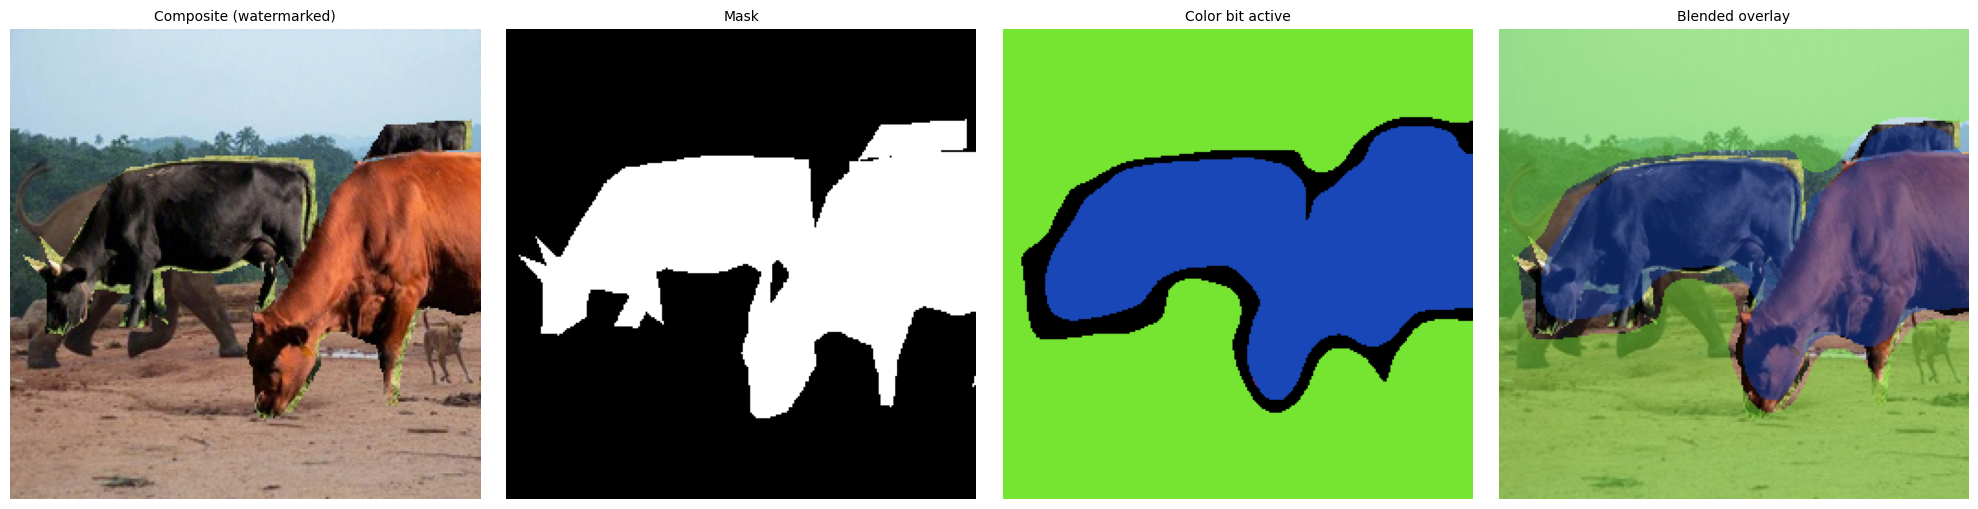

In [2]:
from densemark_tools import recolor_bit_active_blue_light_red

base_dir = repo_root()
_, _, val_transform, val_mask_transform = get_transforms_segmentation(args.image_size)

fig1_dir = args.fig1_dir if os.path.isabs(args.fig1_dir) else os.path.join(base_dir, args.fig1_dir)
p1 = os.path.join(fig1_dir, "000000235857.jpg")
p2 = os.path.join(fig1_dir, "000000237864.jpg")
pm = os.path.join(fig1_dir, "000000235857_mask.png")
for p in (p1, p2, pm):
    if not os.path.isfile(p):
        raise FileNotFoundError(f"Missing file: {p}")

pil1 = Image.open(p1).convert("RGB")
pil2 = Image.open(p2).convert("RGB")
pil_m = val_mask_transform(Image.open(pm).convert("L"))

img1 = val_transform(pil1).unsqueeze(0).to(device)
img2 = val_transform(pil2).unsqueeze(0).to(device)
mask1 = (T.ToTensor()(pil_m) > 0.5).float().unsqueeze(0).to(device)
if mask1.shape[-2:] != img1.shape[-2:]:
    mask1 = F.interpolate(mask1, size=img1.shape[-2:], mode="nearest")

out1 = watermark_model.encode(img1)
out2 = watermark_model.encode(img2)
enc1, msg1 = out1["images_encoded"], out1["msgs_encoded"]
enc2, msg2 = out2["images_encoded"], out2["msgs_encoded"]

composite = enc1 * mask1 + enc2 * (1.0 - mask1)

output_decode = watermark_model.decode(composite)
mult_bit = output_decode["mult_bit"]
color_bit_active = output_decode.get("color_bit_active")

wm_msgs = torch.cat([msg1, msg2], dim=0)
candidates = mult_bit[0]

if candidates.shape[0] == 0:
    print("[mult_bit] No valid candidate vectors detected")
    acc1 = acc2 = 0.0
else:
    match = (candidates.unsqueeze(0) == wm_msgs.unsqueeze(1)).float()
    best_match_per_bit = match.max(dim=1).values
    acc1, acc2 = best_match_per_bit.mean(dim=1).tolist()
    acc1, acc2 = round(acc1, 3), round(acc2, 3)
    print(f"[mult_bit] bit_acc ---> msg1: {acc1:.3f} | msg2: {acc2:.3f}")

base = unnormalize_img(composite).clamp(0, 1)
panels = []

cba = color_bit_active.clone()
if cba.shape[-2:] != base.shape[-2:]:
    cba = F.interpolate(cba, size=base.shape[-2:], mode="bilinear", align_corners=False)
cba = recolor_bit_active_blue_light_red(cba.clamp(0, 1))
active = (cba.sum(dim=1, keepdim=True) > 1e-4).float()
alpha = max(0.0, min(1.0, float(args.color_overlay_alpha)))
blended = (base * (1.0 - alpha * active) + cba * alpha * active).clamp(0, 1)
panels = [
    ("Composite (watermarked)", base),
    ("Mask", mask1.repeat(1, 3, 1, 1)),
    ("Color bit active", cba),
    ("Blended overlay", blended),
]

fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 5))
if len(panels) == 1:
    axes = [axes]
for ax, (title, t) in zip(axes, panels):
    ax.imshow(t[0].permute(1, 2, 0).detach().cpu().numpy().clip(0, 1))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()



## Part 3 · robustness (bit accuracy)


In [3]:
import math
from collections import defaultdict

from densemark_tools import (
    build_wam_sun_val_loader,
    default_validation_augs,
    generate_mask_from_ratio,
    transform_type,
    wam_sun_mean_by_class,
    watermark_bit_accuracy,
)


val_loader = build_wam_sun_val_loader(
    args.data_dir,
    args.val_subdir,
    args.ann_file,
    args.image_size,
    args.batch_size,
    args.workers,
)
validation_augs = default_validation_augs()
bit_acc_by_class = defaultdict(list)

print("Starting validation")

for it, (imgs, _) in enumerate(val_loader):
    if imgs.ndim < 2:
        continue
    if it * args.batch_size >= args.nb_images_eval:
        break

    imgs = imgs.to(device, non_blocking=True)
    combined_imgs = imgs.clone()
    h, w = imgs.shape[-2:]

    output_encode = watermark_model.encode(imgs)
    images_encoded, msgs_encoded = output_encode["images_encoded"], output_encode["msgs_encoded"]

    masks = generate_mask_from_ratio(images_encoded).to(device, non_blocking=True)
    imgs_masked = torch.roll(combined_imgs, shifts=-1, dims=0) * (1 - masks) + images_encoded * masks

    for transform, strengths in validation_augs:
        transform_instance = transform()
        for strength in strengths:
            imgs_aug, masks_aug = transform_instance(imgs_masked, masks, strength)
            if imgs_aug.shape[-2:] != (h, w):
                imgs_aug = F.interpolate(
                    imgs_aug, size=(h, w), mode="bilinear", align_corners=False, antialias=True
                )
                masks_aug = F.interpolate(masks_aug, size=(h, w), mode="nearest")

            tname = str(transform.__name__)
            aug_cls = transform_type(tname.lower())
            bit_acc = watermark_bit_accuracy(msgs_encoded, watermark_model.decode(imgs_aug)["msgs_decoded"])
            if not math.isnan(bit_acc):
                bit_acc_by_class[aug_cls].append(bit_acc)

metrics = wam_sun_mean_by_class(bit_acc_by_class)
metrics = {k: round(v, 3) for k, v in metrics.items()}
print("Validation finished")
for aug_cls in ("geo", "value", "iden"):
    print(f"class={aug_cls}  bit_acc={metrics[aug_cls]:.3f}")

loading annotations into memory...
Done (t=0.59s)
creating index...
index created!
Starting validation


Validation finished
class=geo  bit_acc=0.989
class=value  bit_acc=0.998
class=iden  bit_acc=1.000
